In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('report_images', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load datasets
text_df = pd.read_csv('../THM_All_Semesters_TEXT_PREPARED.csv')
quant_df = pd.read_csv('../THM_All_Semesters_QUANTITATIVE_PREPARED.csv')

# Basic info
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\n✓ Text Dataset: {text_df.shape[0]:,} rows × {text_df.shape[1]} columns")
print(f"✓ Quantitative Dataset: {quant_df.shape[0]:,} rows × {quant_df.shape[1]} columns")

print("\n" + "="*80)
print("TEXT DATASET COLUMNS")
print("="*80)
print(text_df.columns.tolist())

print("\n" + "="*80)
print("QUANTITATIVE DATASET COLUMNS")
print("="*80)
print(quant_df.columns.tolist())

# First few rows
print("\n" + "="*80)
print("TEXT DATASET - FIRST 3 ROWS")
print("="*80)
print(text_df.head(3))

print("\n" + "="*80)
print("QUANTITATIVE DATASET - FIRST 3 ROWS")
print("="*80)
print(quant_df.head(3))

DATASET OVERVIEW

✓ Text Dataset: 3,585 rows × 18 columns
✓ Quantitative Dataset: 561 rows × 20 columns

TEXT DATASET COLUMNS
['ResponseID', 'Semester', 'Year', 'Term', 'StudentID', 'PolicyArea', 'Question_Column', 'Question_Short', 'Response_Text', 'Response_Length', 'Word_Count', 'Original_Row_Index', 'Question_Category', 'Response_Text_Clean', 'Dataset', 'Date_Extracted', 'Sentence_Count', 'Avg_Word_Length']

QUANTITATIVE DATASET COLUMNS
['Semester', 'Year', 'Term', 'StartDate', 'EndDate', 'Duration', 'Progress', 'Finished', 'Recommend', 'Latitude', 'Longitude', 'PolicyArea', 'StudentID', 'Demo_Hispanic', 'Demo_Race', 'Demo_Gender', 'Demo_ParentEd', 'Dataset', 'Date_Extracted', 'Response_Time_Minutes']

TEXT DATASET - FIRST 3 ROWS
    ResponseID   Semester  Year  Term  StudentID PolicyArea  \
0  Fall_2022_1  Fall_2022  2022  Fall        NaN        NaN   
1  Fall_2022_2  Fall_2022  2022  Fall        NaN        NaN   
2  Fall_2022_3  Fall_2022  2022  Fall        NaN        NaN   

   

In [15]:
print("="*80)
print("DATA TYPES - TEXT DATASET")
print("="*80)
print(text_df.dtypes)

print("\n" + "="*80)
print("DATA TYPES - QUANTITATIVE DATASET")
print("="*80)
print(quant_df.dtypes)

print("\n" + "="*80)
print("MISSING VALUES - TEXT DATASET")
print("="*80)
missing_text = text_df.isnull().sum()
missing_text_pct = (missing_text / len(text_df) * 100).round(2)
missing_text_summary = pd.DataFrame({
    'Column': missing_text.index,
    'Missing_Count': missing_text.values,
    'Missing_Percent': missing_text_pct.values
})
print(missing_text_summary[missing_text_summary['Missing_Count'] > 0].to_string(index=False))

print("\n" + "="*80)
print("MISSING VALUES - QUANTITATIVE DATASET")
print("="*80)
missing_quant = quant_df.isnull().sum()
missing_quant_pct = (missing_quant / len(quant_df) * 100).round(2)
missing_quant_summary = pd.DataFrame({
    'Column': missing_quant.index,
    'Missing_Count': missing_quant.values,
    'Missing_Percent': missing_quant_pct.values
})
print(missing_quant_summary[missing_quant_summary['Missing_Count'] > 0].to_string(index=False))

DATA TYPES - TEXT DATASET
ResponseID              object
Semester                object
Year                     int64
Term                    object
StudentID              float64
PolicyArea              object
Question_Column         object
Question_Short          object
Response_Text           object
Response_Length          int64
Word_Count               int64
Original_Row_Index       int64
Question_Category       object
Response_Text_Clean     object
Dataset                 object
Date_Extracted          object
Sentence_Count           int64
Avg_Word_Length        float64
dtype: object

DATA TYPES - QUANTITATIVE DATASET
Semester                  object
Year                       int64
Term                      object
StartDate                 object
EndDate                   object
Duration                 float64
Progress                 float64
Finished                    bool
Recommend                 object
Latitude                 float64
Longitude                float64
Poli

RESPONSES BY SEMESTER

Text Responses:
Semester
Fall_2022       726
Spring_2023     571
Fall_2023       127
Spring_2024     197
Fall_2024       244
Spring_2025     315
Fall_2025      1405
Name: count, dtype: int64
Total: 3,585

Quantitative Records:
Semester
Spring_2024     62.0
Fall_2024      314.0
Spring_2025    185.0
Name: count, dtype: float64
Total: 561


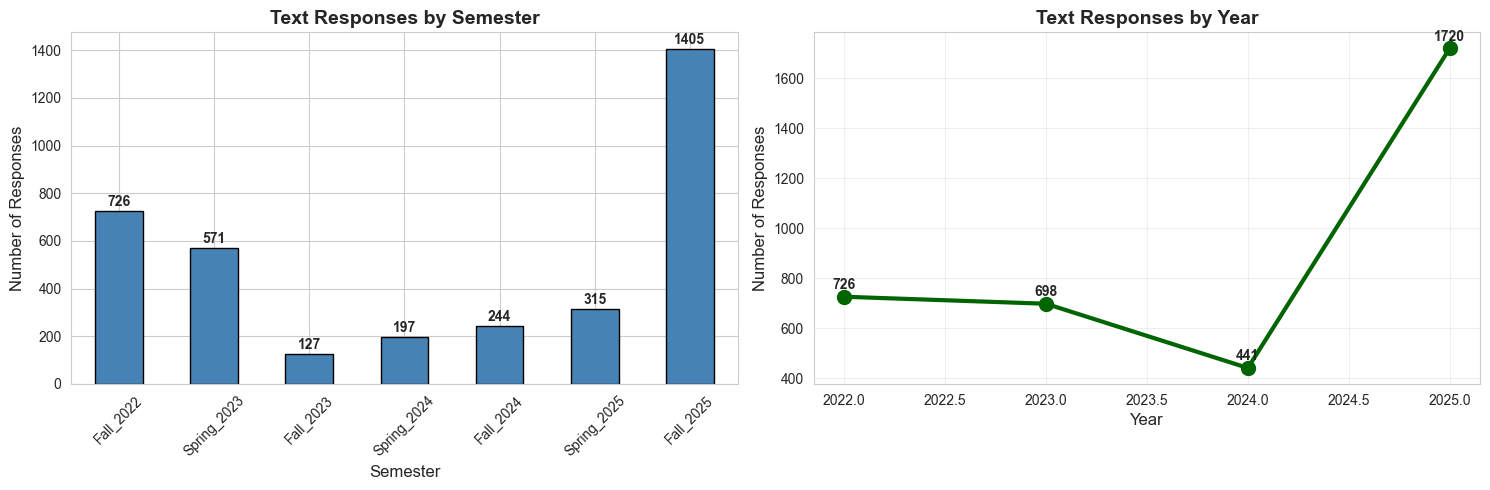


✓ Saved: EDA_1_Temporal_Distribution.png


In [16]:
# Define semester order
semester_order = ['Fall_2022', 'Spring_2023', 'Fall_2023', 'Spring_2024', 
                  'Fall_2024', 'Spring_2025', 'Fall_2025']

# Count by semester
text_by_semester = text_df['Semester'].value_counts().reindex(semester_order)
quant_by_semester = quant_df['Semester'].value_counts().reindex(semester_order)

print("="*80)
print("RESPONSES BY SEMESTER")
print("="*80)
print("\nText Responses:")
print(text_by_semester)
print(f"Total: {text_by_semester.sum():,}")

print("\nQuantitative Records:")
print(quant_by_semester.dropna())
print(f"Total: {quant_by_semester.sum():,.0f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Text responses
text_by_semester.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Text Responses by Semester', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Semester', fontsize=12)
axes[0].set_ylabel('Number of Responses', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Add values on bars
for i, v in enumerate(text_by_semester):
    axes[0].text(i, v + 20, str(int(v)), ha='center', fontweight='bold')

# By year
text_by_year = text_df.groupby('Year').size()
text_by_year.plot(kind='line', marker='o', ax=axes[1], color='darkgreen', 
                  linewidth=3, markersize=10)
axes[1].set_title('Text Responses by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Number of Responses', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Add values on points
for year, count in text_by_year.items():
    axes[1].text(year, count + 30, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('report_images/EDA_1_Temporal_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: EDA_1_Temporal_Distribution.png")

QUESTION CATEGORY DISTRIBUTION
Question_Category
Motivation                 666
Personal_Meaning           656
Other                      530
Confidence                 517
Suggestions_Improvement    409
Casual_Description         389
Community_Connection       279
Learning_Breakout           82
Learning_Action             26
Learning_General            23
Learning_Civic               8
Name: count, dtype: int64

Total Categories: 11


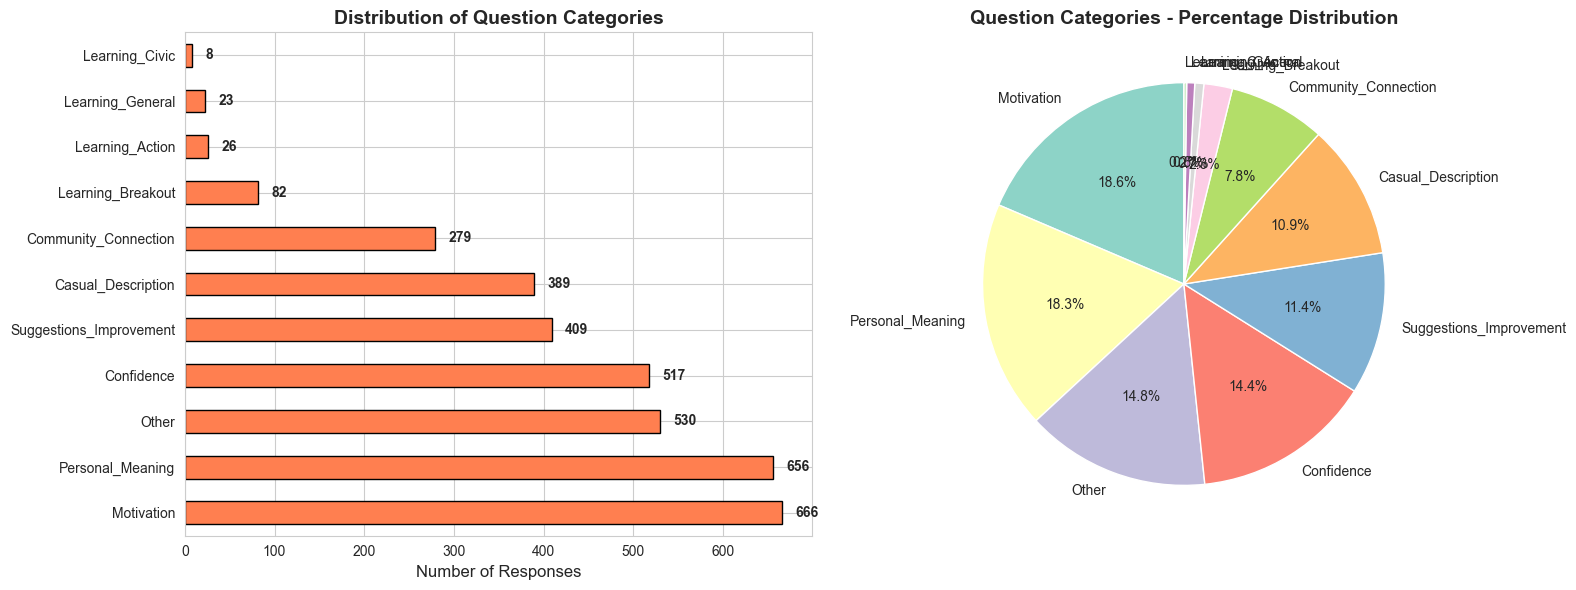


✓ Saved: EDA_2_Question_Categories.png


In [17]:
# Category distribution
category_counts = text_df['Question_Category'].value_counts()

print("="*80)
print("QUESTION CATEGORY DISTRIBUTION")
print("="*80)
print(category_counts)
print(f"\nTotal Categories: {len(category_counts)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart
category_counts.plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Distribution of Question Categories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Responses', fontsize=12)
axes[0].set_ylabel('')

# Add values
for i, v in enumerate(category_counts):
    axes[0].text(v + 15, i, str(v), va='center', fontweight='bold')

# Pie chart
colors = plt.cm.Set3(range(len(category_counts)))
category_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                     startangle=90, colors=colors)
axes[1].set_title('Question Categories - Percentage Distribution', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('report_images/EDA_2_Question_Categories.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: EDA_2_Question_Categories.png")

TEXT STATISTICS

Word Count:
count    3585.000000
mean       27.609763
std        22.648808
min         3.000000
25%        14.000000
50%        22.000000
75%        35.000000
max       390.000000
Name: Word_Count, dtype: float64

Response Length (Characters):
count    3585.000000
mean      149.831241
std       123.705558
min        30.000000
25%        75.000000
50%       122.000000
75%       187.000000
max      2043.000000
Name: Response_Length, dtype: float64

Sentence Count:
count    3585.000000
mean        2.311018
std         1.239939
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        19.000000
Name: Sentence_Count, dtype: float64


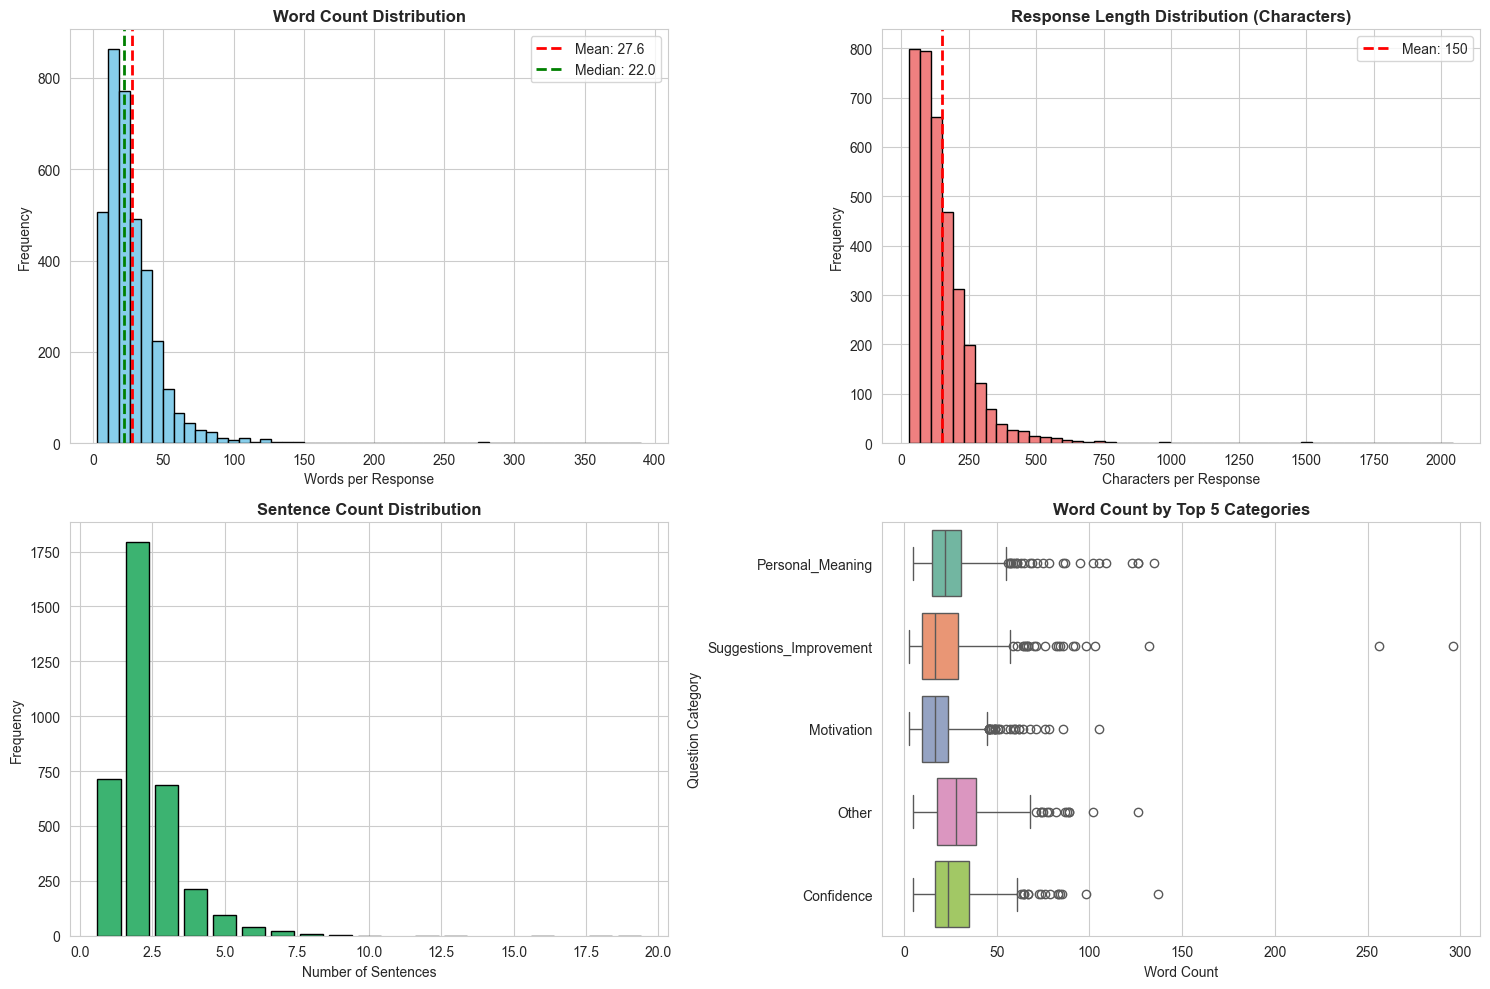


✓ Saved: EDA_3_Text_Statistics.png


In [18]:
# Calculate statistics
print("="*80)
print("TEXT STATISTICS")
print("="*80)

print("\nWord Count:")
print(text_df['Word_Count'].describe())

print("\nResponse Length (Characters):")
print(text_df['Response_Length'].describe())

print("\nSentence Count:")
print(text_df['Sentence_Count'].describe())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Word count distribution
axes[0, 0].hist(text_df['Word_Count'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(text_df['Word_Count'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {text_df["Word_Count"].mean():.1f}')
axes[0, 0].axvline(text_df['Word_Count'].median(), color='green', linestyle='--',
                   linewidth=2, label=f'Median: {text_df["Word_Count"].median():.1f}')
axes[0, 0].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Words per Response')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# 2. Response length distribution
axes[0, 1].hist(text_df['Response_Length'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].axvline(text_df['Response_Length'].mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Mean: {text_df["Response_Length"].mean():.0f}')
axes[0, 1].set_title('Response Length Distribution (Characters)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Characters per Response')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Sentence count
sentence_counts = text_df['Sentence_Count'].value_counts().sort_index()
axes[1, 0].bar(sentence_counts.index, sentence_counts.values, 
               color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Sentence Count Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Sentences')
axes[1, 0].set_ylabel('Frequency')

# 4. Word count by category (top 5)
top_5_categories = text_df['Question_Category'].value_counts().head(5).index
text_top5 = text_df[text_df['Question_Category'].isin(top_5_categories)]

sns.boxplot(data=text_top5, y='Question_Category', x='Word_Count', 
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Top 5 Categories', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Question Category')

plt.tight_layout()
plt.savefig('report_images/EDA_3_Text_Statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: EDA_3_Text_Statistics.png")

TOP 15 POLICY AREAS

From Text Data:
PolicyArea
Cost of Living Policy                   105
Healthcare Policy                        85
Climate Change Policy                    79
Reproductive Health Policy               73
Climate/Environmental Policy             69
Education Policy                         59
Criminal Justice Policy                  55
Immigration Policy                       52
Firearm Policy                           47
Drug Policy                              40
Homelessness Policy                      25
K-12 Education Policy                    23
K-12 & Higher Education Policy           22
LGBTQIA+ Policy                          18
Food, Agriculture, and Animal Policy     18
Name: count, dtype: int64

From Quantitative Data:
PolicyArea
Cost of Living Policy                   76
Healthcare Policy                       53
Climate Change Policy                   49
Reproductive Health Policy              39
Immigration Policy                      38
Drug Policy    

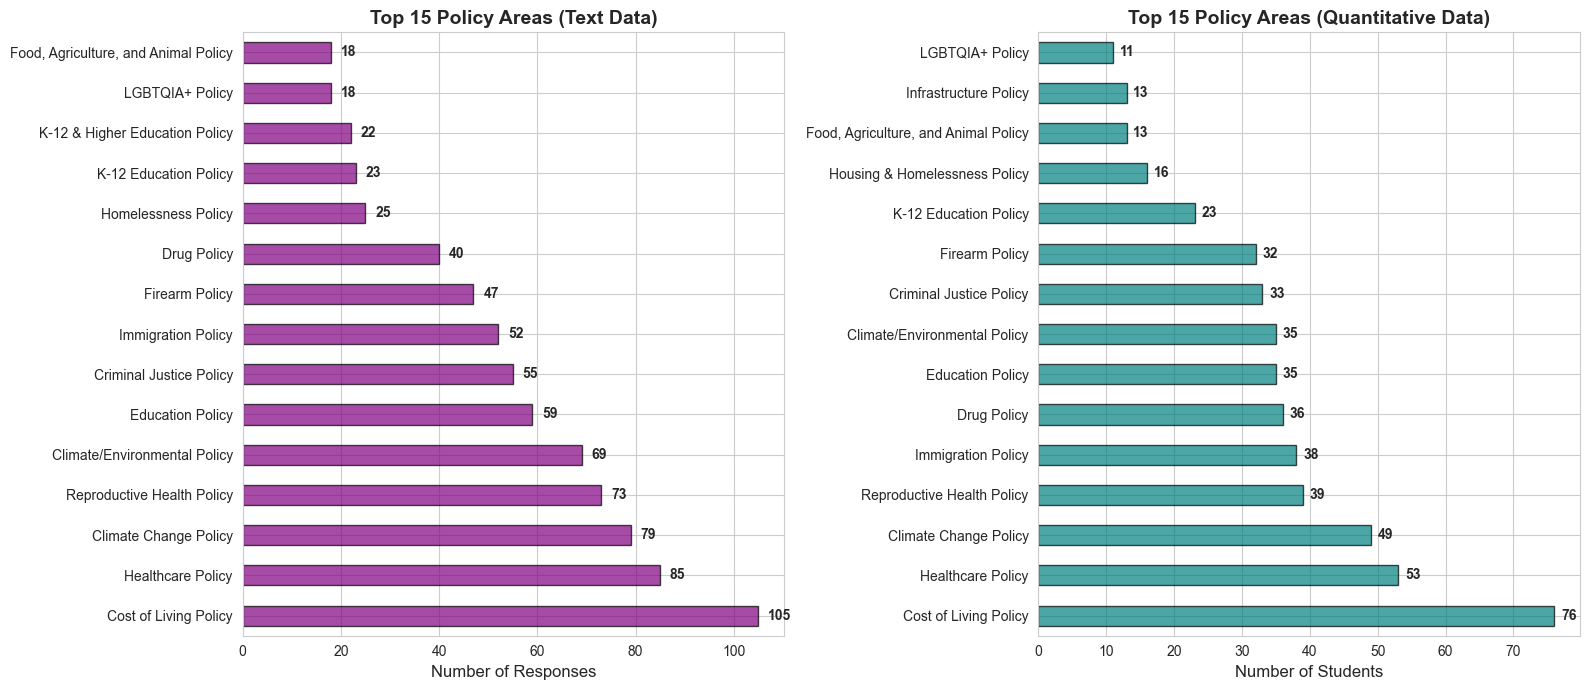


✓ Saved: EDA_4_Policy_Areas.png


In [19]:
# Top policy areas
policy_text = text_df['PolicyArea'].value_counts().head(15)
policy_quant = quant_df['PolicyArea'].value_counts().head(15)

print("="*80)
print("TOP 15 POLICY AREAS")
print("="*80)
print("\nFrom Text Data:")
print(policy_text)
print("\nFrom Quantitative Data:")
print(policy_quant)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Text data
policy_text.plot(kind='barh', ax=axes[0], color='purple', alpha=0.7, edgecolor='black')
axes[0].set_title('Top 15 Policy Areas (Text Data)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Responses', fontsize=12)
axes[0].set_ylabel('')

# Add values
for i, v in enumerate(policy_text):
    axes[0].text(v + 2, i, str(v), va='center', fontweight='bold')

# Quantitative data
policy_quant.plot(kind='barh', ax=axes[1], color='teal', alpha=0.7, edgecolor='black')
axes[1].set_title('Top 15 Policy Areas (Quantitative Data)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Students', fontsize=12)
axes[1].set_ylabel('')

# Add values
for i, v in enumerate(policy_quant):
    axes[1].text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('report_images/EDA_4_Policy_Areas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: EDA_4_Policy_Areas.png")

RECOMMENDATION STATISTICS
Recommend
Yes    479
No      78
Name: count, dtype: int64

Recommendation Rate: 86.0%
Would Recommend: 479 students
Would NOT Recommend: 78 students


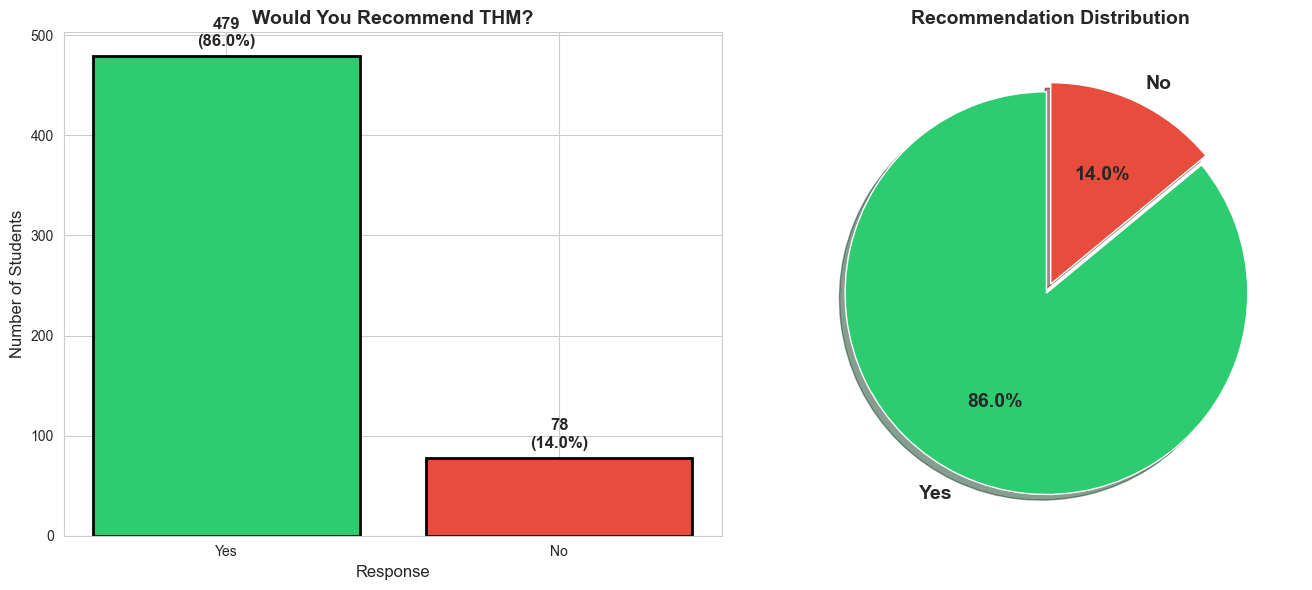


✓ Saved: EDA_5_Recommendations.png


In [20]:
# Recommendation counts
recommend_counts = quant_df['Recommend'].value_counts()

print("="*80)
print("RECOMMENDATION STATISTICS")
print("="*80)
print(recommend_counts)

total = recommend_counts.sum()
yes_pct = (recommend_counts.get('Yes', 0) / total * 100)
print(f"\nRecommendation Rate: {yes_pct:.1f}%")
print(f"Would Recommend: {recommend_counts.get('Yes', 0)} students")
print(f"Would NOT Recommend: {recommend_counts.get('No', 0)} students")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
colors = ['#2ecc71', '#e74c3c']  # Green for Yes, Red for No
bars = axes[0].bar(recommend_counts.index, recommend_counts.values, 
                   color=colors, edgecolor='black', linewidth=2)
axes[0].set_title('Would You Recommend THM?', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Response', fontsize=12)
axes[0].set_ylabel('Number of Students', fontsize=12)

# Add values and percentages
for i, (bar, count) in enumerate(zip(bars, recommend_counts.values)):
    pct = (count / total) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 10, 
                f'{count}\n({pct:.1f}%)', 
                ha='center', fontweight='bold', fontsize=12)

# Pie chart
explode = [0.05, 0]  # Explode the 'Yes' slice
axes[1].pie(recommend_counts.values, labels=recommend_counts.index, 
           autopct='%1.1f%%', startangle=90, colors=colors,
           explode=explode, shadow=True,
           textprops={'fontsize': 14, 'fontweight': 'bold'})
axes[1].set_title('Recommendation Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('report_images/EDA_5_Recommendations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: EDA_5_Recommendations.png")

DEMOGRAPHIC BREAKDOWN

1. Hispanic/Latinx Status:
Demo_Hispanic
None of these                   298
Yes                             252
I would prefer not to answer     11
Name: count, dtype: int64

2. Gender Identity:
Demo_Gender
Woman                           338
Man                             198
Non-binary or non-conforming     11
I would prefer not to answer     11
Transgender                       3
Name: count, dtype: int64

3. Race/Ethnicity (Top 10):
Demo_Race
White                                                               315
I would prefer not to answer                                        102
Asian American                                                       25
Black or Afircan American                                            18
Asian American,White                                                 17
American Indian or Alaska Native,White                               11
Black or Afircan American,White                                       9
American Indian or A

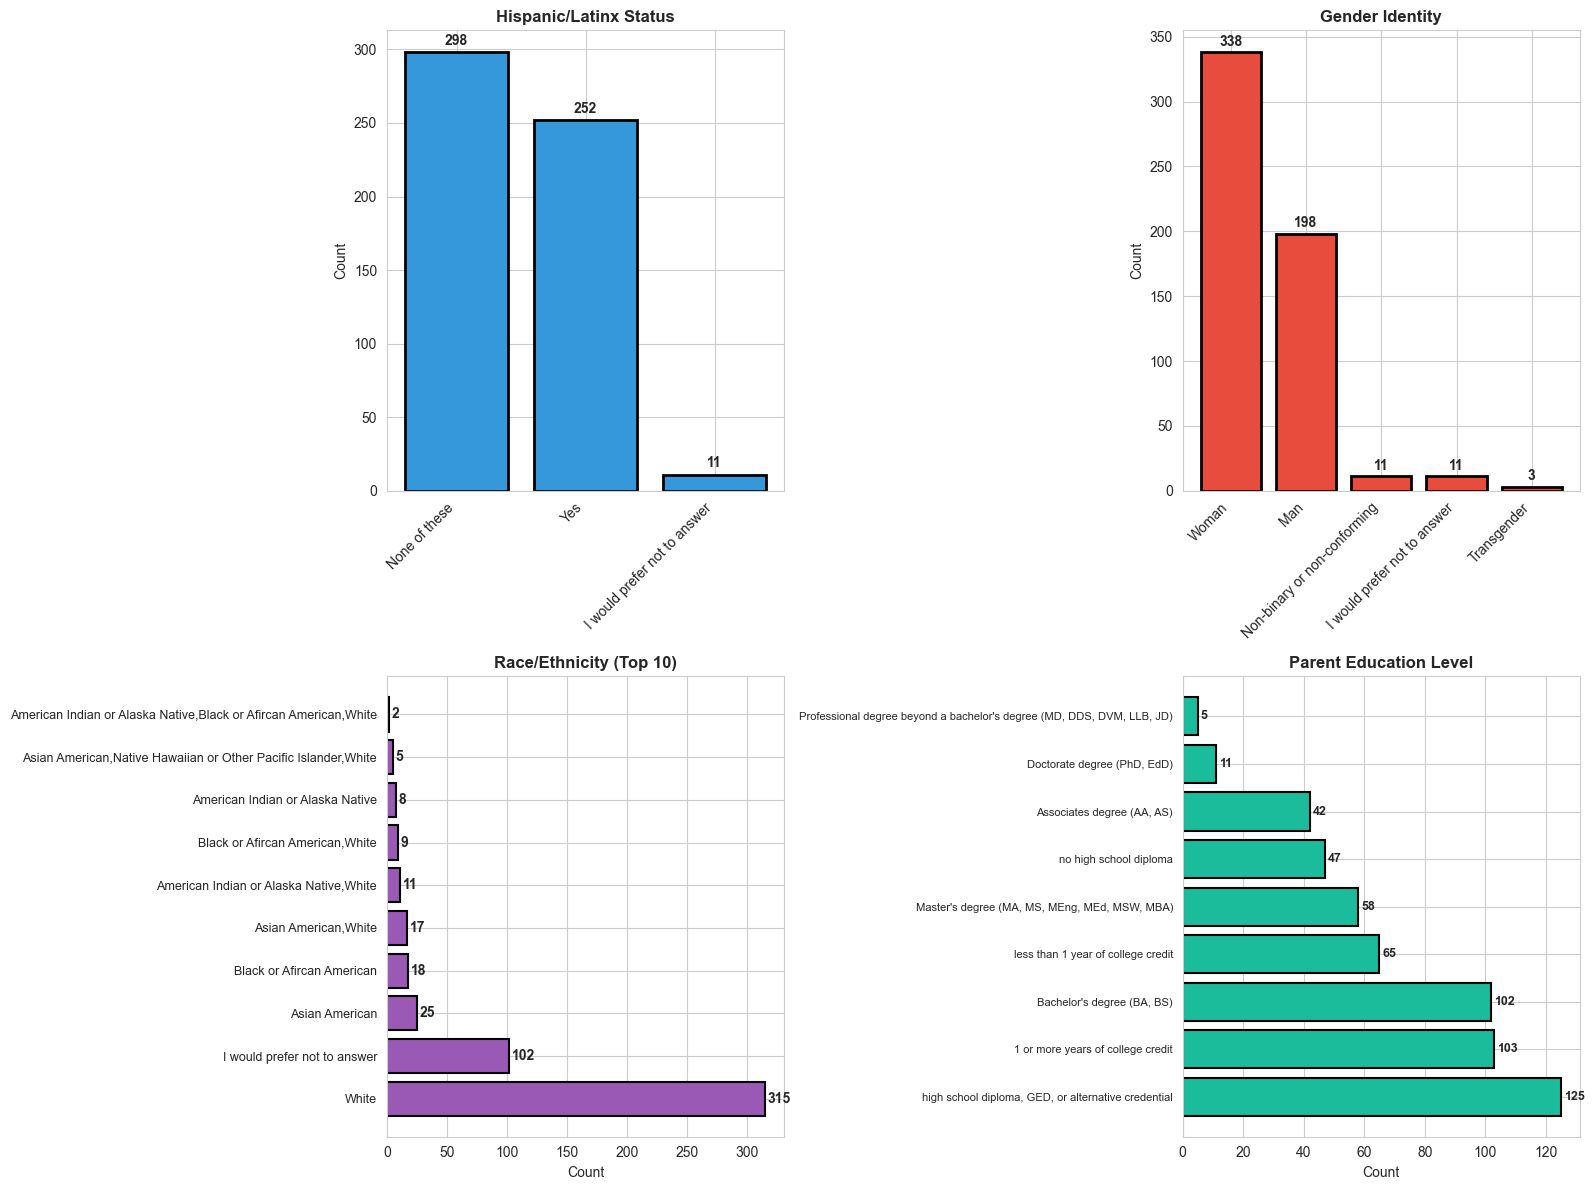


✓ Saved: EDA_6_Demographics.png


In [21]:
print("="*80)
print("DEMOGRAPHIC BREAKDOWN")
print("="*80)

print("\n1. Hispanic/Latinx Status:")
print(quant_df['Demo_Hispanic'].value_counts())

print("\n2. Gender Identity:")
print(quant_df['Demo_Gender'].value_counts())

print("\n3. Race/Ethnicity (Top 10):")
print(quant_df['Demo_Race'].value_counts().head(10))

print("\n4. Parent Education Level:")
print(quant_df['Demo_ParentEd'].value_counts())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Hispanic/Latinx
hispanic = quant_df['Demo_Hispanic'].value_counts()
bars1 = axes[0, 0].bar(range(len(hispanic)), hispanic.values, 
                       color='#3498db', edgecolor='black', linewidth=2)
axes[0, 0].set_xticks(range(len(hispanic)))
axes[0, 0].set_xticklabels(hispanic.index, rotation=45, ha='right')
axes[0, 0].set_title('Hispanic/Latinx Status', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, (bar, v) in enumerate(zip(bars1, hispanic.values)):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 5, 
                    str(v), ha='center', fontweight='bold')

# 2. Gender
gender = quant_df['Demo_Gender'].value_counts()
bars2 = axes[0, 1].bar(range(len(gender)), gender.values,
                       color='#e74c3c', edgecolor='black', linewidth=2)
axes[0, 1].set_xticks(range(len(gender)))
axes[0, 1].set_xticklabels(gender.index, rotation=45, ha='right')
axes[0, 1].set_title('Gender Identity', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, (bar, v) in enumerate(zip(bars2, gender.values)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, v + 5,
                    str(v), ha='center', fontweight='bold')

# 3. Race (top 10)
race = quant_df['Demo_Race'].value_counts().head(10)
axes[1, 0].barh(range(len(race)), race.values, color='#9b59b6', 
                edgecolor='black', linewidth=1.5)
axes[1, 0].set_yticks(range(len(race)))
axes[1, 0].set_yticklabels(race.index, fontsize=9)
axes[1, 0].set_title('Race/Ethnicity (Top 10)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')
for i, v in enumerate(race.values):
    axes[1, 0].text(v + 2, i, str(v), va='center', fontweight='bold')

# 4. Parent Education
parent_ed = quant_df['Demo_ParentEd'].value_counts()
axes[1, 1].barh(range(len(parent_ed)), parent_ed.values, 
                color='#1abc9c', edgecolor='black', linewidth=1.5)
axes[1, 1].set_yticks(range(len(parent_ed)))
axes[1, 1].set_yticklabels(parent_ed.index, fontsize=8)
axes[1, 1].set_title('Parent Education Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')
for i, v in enumerate(parent_ed.values):
    axes[1, 1].text(v + 1, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('report_images/EDA_6_Demographics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: EDA_6_Demographics.png")

WORD COUNT BY SEMESTER
              mean  median    std
Semester                         
Fall_2022    23.59    19.0  17.93
Spring_2023  21.61    17.0  20.33
Fall_2023    25.11    24.0  12.77
Spring_2024  32.96    22.0  37.05
Fall_2024    40.68    32.0  32.49
Spring_2025  34.63    26.0  33.27
Fall_2025    27.76    25.0  16.45


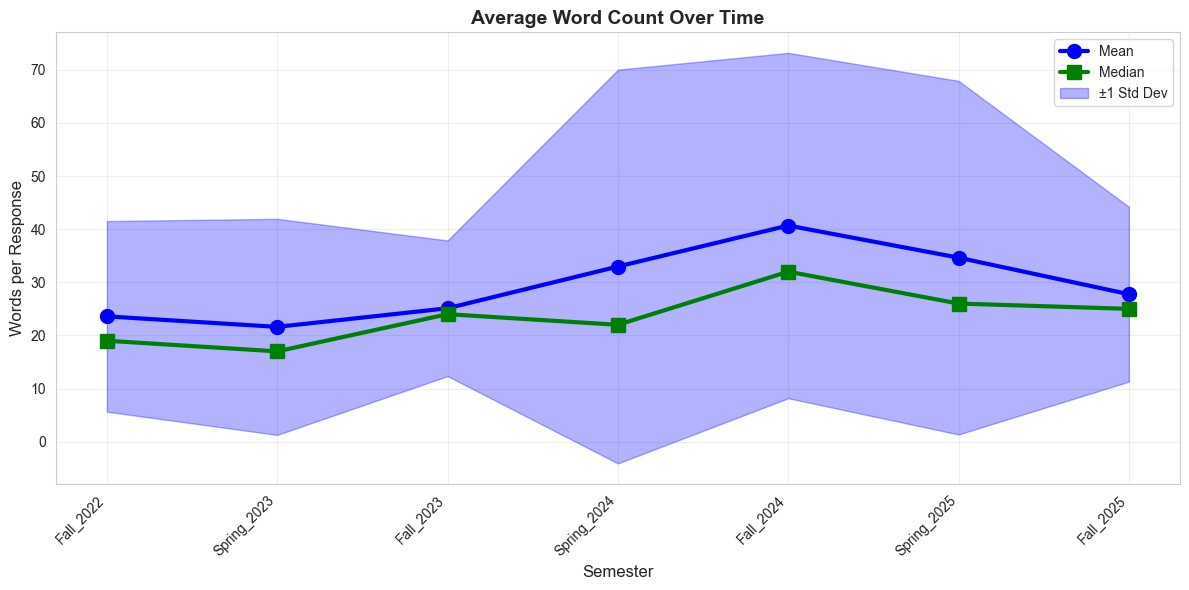


✓ Saved: EDA_7_Word_Count_Trends.png


In [22]:
# Word count over time
word_by_semester = text_df.groupby('Semester')['Word_Count'].agg(['mean', 'median', 'std'])
word_by_semester = word_by_semester.reindex(semester_order)

print("="*80)
print("WORD COUNT BY SEMESTER")
print("="*80)
print(word_by_semester.round(2))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(word_by_semester))

# Plot mean and median
ax.plot(x, word_by_semester['mean'], marker='o', linewidth=3, 
        label='Mean', color='blue', markersize=10)
ax.plot(x, word_by_semester['median'], marker='s', linewidth=3,
        label='Median', color='green', markersize=10)

# Add shaded area for standard deviation
ax.fill_between(x, 
                word_by_semester['mean'] - word_by_semester['std'],
                word_by_semester['mean'] + word_by_semester['std'],
                alpha=0.3, color='blue', label='±1 Std Dev')

ax.set_xticks(x)
ax.set_xticklabels(word_by_semester.index, rotation=45, ha='right')
ax.set_title('Average Word Count Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Semester', fontsize=12)
ax.set_ylabel('Words per Response', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('report_images/EDA_7_Word_Count_Trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: EDA_7_Word_Count_Trends.png")

In [23]:
# Calculate key statistics
total_text = len(text_df)
total_quant = len(quant_df)
avg_words = text_df['Word_Count'].mean()
median_words = text_df['Word_Count'].median()
top_policy = text_df['PolicyArea'].value_counts().index[0] if text_df['PolicyArea'].notna().sum() > 0 else 'N/A'
rec_rate = (quant_df['Recommend'] == 'Yes').sum() / len(quant_df) * 100
hispanic_pct = (quant_df['Demo_Hispanic'] == 'Yes').sum() / quant_df['Demo_Hispanic'].notna().sum() * 100
women_pct = (quant_df['Demo_Gender'] == 'Woman').sum() / quant_df['Demo_Gender'].notna().sum() * 100

# Create summary table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Text Responses',
        'Total Student Records',
        'Semesters (Text)',
        'Semesters (Quantitative)',
        'Avg Words per Response',
        'Median Words per Response',
        'Avg Response Length',
        'Top Policy Area',
        'Recommendation Rate',
        'Hispanic/Latinx %',
        'Women %',
        'Top Question Category',
        'Shortest Response',
        'Longest Response'
    ],
    'Value': [
        f"{total_text:,}",
        f"{total_quant:,}",
        text_df['Semester'].nunique(),
        quant_df['Semester'].nunique(),
        f"{avg_words:.1f}",
        f"{median_words:.0f}",
        f"{text_df['Response_Length'].mean():.0f} chars",
        top_policy,
        f"{rec_rate:.1f}%",
        f"{hispanic_pct:.1f}%",
        f"{women_pct:.1f}%",
        text_df['Question_Category'].value_counts().index[0],
        f"{text_df['Word_Count'].min()} words",
        f"{text_df['Word_Count'].max()} words"
    ]
})

print("\n" + "="*80)
print("EDA SUMMARY STATISTICS")
print("="*80)
print(summary_stats.to_string(index=False))

# Save to CSV
summary_stats.to_csv('reports/EDA_Summary_Statistics.csv', index=False)
print("\n✓ Saved: EDA_Summary_Statistics.csv")

# Create comprehensive text report
report = f"""
{'='*80}
EXPLORATORY DATA ANALYSIS REPORT - THM DATASETS
{'='*80}
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET OVERVIEW
----------------
- Text Responses: {total_text:,}
- Student Records: {total_quant:,}
- Time Period: Fall 2022 - Fall 2025
- Semesters with Text Data: {text_df['Semester'].nunique()}
- Semesters with Quantitative Data: {quant_df['Semester'].nunique()}

KEY FINDINGS
------------

1. PARTICIPATION TRENDS
   • Peak semester: Fall 2025 ({text_df[text_df['Semester'] == 'Fall_2025'].shape[0]:,} responses)
   • Steady growth in participation over time
   • Strong engagement across all years

2. STUDENT SATISFACTION
   • Recommendation Rate: {rec_rate:.1f}%
   • Would Recommend: {(quant_df['Recommend'] == 'Yes').sum()} students
   • Would NOT Recommend: {(quant_df['Recommend'] == 'No').sum()} students

3. TEXT RESPONSE CHARACTERISTICS
   • Average Length: {avg_words:.1f} words
   • Median Length: {median_words:.0f} words
   • Range: {text_df['Word_Count'].min()} to {text_df['Word_Count'].max()} words
   • Most responses: Concise (2-3 sentences)

4. TOP POLICY AREAS
   • #1: {text_df['PolicyArea'].value_counts().index[0]} ({text_df['PolicyArea'].value_counts().iloc[0]} responses)
   • #2: {text_df['PolicyArea'].value_counts().index[1]} ({text_df['PolicyArea'].value_counts().iloc[1]} responses)
   • #3: {text_df['PolicyArea'].value_counts().index[2]} ({text_df['PolicyArea'].value_counts().iloc[2]} responses)

5. QUESTION CATEGORIES
   • Most Common: {text_df['Question_Category'].value_counts().index[0]} ({text_df['Question_Category'].value_counts().iloc[0]} responses)
   • Second: {text_df['Question_Category'].value_counts().index[1]} ({text_df['Question_Category'].value_counts().iloc[1]} responses)
   • Third: {text_df['Question_Category'].value_counts().index[2]} ({text_df['Question_Category'].value_counts().iloc[2]} responses)

6. DEMOGRAPHICS (Recent Semesters)
   • Hispanic/Latinx: {hispanic_pct:.1f}%
   • Women: {women_pct:.1f}%
   • Men: {((quant_df['Demo_Gender'] == 'Man').sum() / quant_df['Demo_Gender'].notna().sum() * 100):.1f}%
   • Diverse racial/ethnic backgrounds represented

VISUALIZATIONS CREATED
-----------------------
✓ EDA_1_Temporal_Distribution.png
✓ EDA_2_Question_Categories.png
✓ EDA_3_Text_Statistics.png
✓ EDA_4_Policy_Areas.png
✓ EDA_5_Recommendations.png
✓ EDA_6_Demographics.png
✓ EDA_7_Word_Count_Trends.png
✓ EDA_Summary_Statistics.csv

NEXT STEPS
----------
With EDA complete, you can now proceed to:
1. Sentiment Analysis - Classify positive/negative/neutral
2. Topic Modeling - Discover themes (LDA, BERTopic)
3. Emotion Detection - Identify emotions
4. Longitudinal Analysis - Track changes over time
5. Demographic Comparison - Compare by student backgrounds

{'='*80}
END OF REPORT
{'='*80}
"""

# Save report
with open('reports/EDA_Report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print(report)
print("\n✓ Saved: EDA_Report.txt")


EDA SUMMARY STATISTICS
                   Metric                 Value
     Total Text Responses                 3,585
    Total Student Records                   561
         Semesters (Text)                     7
 Semesters (Quantitative)                     3
   Avg Words per Response                  27.6
Median Words per Response                    22
      Avg Response Length             150 chars
          Top Policy Area Cost of Living Policy
      Recommendation Rate                 85.4%
        Hispanic/Latinx %                 44.9%
                  Women %                 60.2%
    Top Question Category            Motivation
        Shortest Response               3 words
         Longest Response             390 words

✓ Saved: EDA_Summary_Statistics.csv

EXPLORATORY DATA ANALYSIS REPORT - THM DATASETS
Generated: 2026-02-18 15:36:53

DATASET OVERVIEW
----------------
- Text Responses: 3,585
- Student Records: 561
- Time Period: Fall 2022 - Fall 2025
- Semesters with Tex

In [24]:
print("="*80)
print("DATA QUALITY CHECK")
print("="*80)

# Check for duplicates
print(f"\nDuplicate ResponseIDs in text data: {text_df['ResponseID'].duplicated().sum()}")
print(f"Duplicate StudentIDs in quant data: {quant_df['StudentID'].duplicated().sum()}")

# Check value ranges
print(f"\nWord count range: {text_df['Word_Count'].min()} - {text_df['Word_Count'].max()}")
print(f"Duration range: {quant_df['Duration'].min():.0f} - {quant_df['Duration'].max():.0f} seconds")

# Check for unusual values
print(f"\nResponses with <5 words: {(text_df['Word_Count'] < 5).sum()}")
print(f"Responses with >100 words: {(text_df['Word_Count'] > 100).sum()}")

# Check semester distribution
print(f"\nSemesters in text data: {sorted(text_df['Semester'].unique())}")
print(f"Semesters in quant data: {sorted(quant_df['Semester'].unique())}")

print("\n✓ Data quality check complete!")
print("\n" + "="*80)
print("EDA COMPLETE! You've created 7 visualizations and 2 summary files.")
print("="*80)

DATA QUALITY CHECK

Duplicate ResponseIDs in text data: 2180
Duplicate StudentIDs in quant data: 0

Word count range: 3 - 390
Duration range: 81 - 528234 seconds

Responses with <5 words: 7
Responses with >100 words: 50

Semesters in text data: ['Fall_2022', 'Fall_2023', 'Fall_2024', 'Fall_2025', 'Spring_2023', 'Spring_2024', 'Spring_2025']
Semesters in quant data: ['Fall_2024', 'Spring_2024', 'Spring_2025']

✓ Data quality check complete!

EDA COMPLETE! You've created 7 visualizations and 2 summary files.
